In [ ]:
import torch

# Torch (and PyTorch) PyTorch is one of the most popular frameworks for
#  developing and training machine learning and deep learning models.

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# CUDA (Compute Unified Device Architecture) is a parallel computing platform
# and programming model developed by NVIDIA for their GPUs. CUDA harness the
# highly parallel processing power of GPUs to perform general-purpose computing
# tasks (i.e., tasks beyond traditional graphics rendering).


Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Basic image generation with Diffusers
The Diffusers library is developed and maintained by Hugging Face. It comes with several diffusion models for image, video, and audio generation.

You can find the source code and documentation on GitHub:

https://github.com/huggingface/diffusers

In [ ]:
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(

    # "runwayml/stable-diffusion-v1-5", # SD 1.5 uses CLIP ViT-L as its text encoder, which caps at 77 tokens and treats the prompt more as a bag of weighted concepts than as a sentence. So it responds to comma-separated tags, not natural language, and front-loaded terms carry more weight.

    # "Lykon/dreamshaper-8",   # community fine-tune of SD 1.5 by Lykon,

    "stabilityai/sd-turbo", # It's Stable Diffusion 2.1, it requires num_inference_steps=1, guidance_scale=0.0
    torch_dtype=torch.float16,
    ).to(device)

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/1 [00:00<?, ?it/s]

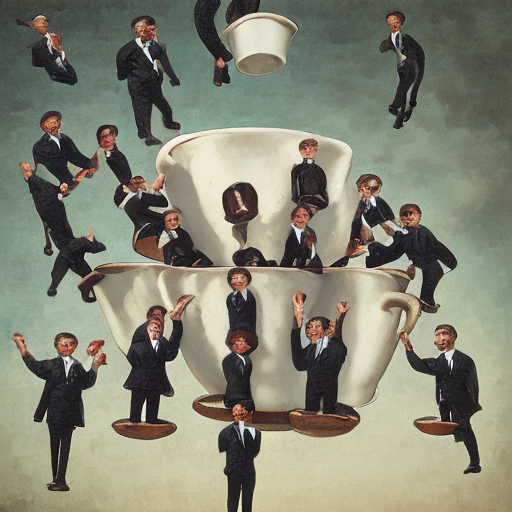

In [ ]:
# prompt = (
# "Multiple men in suits are carried to the edge of a giant full coffee cup by small spoons, ready to jump in"
# "Painterly on heavy grainy canvas, zoomed out, isometric, surrealist poster, collage, shallow depth of field, film grain, detailed"
# )

# prompt = (
# "multiple men in suits standing on small spoons are carried to the edge of a giant full coffee cup, ready to jump in"
# "the sky in the background begins to melt"
# "Painterly on heavy grainy canvas, zoomed out, isometric, surrealist poster, collage, shallow depth of field, film grain, detailed"
# )

# prompt = (
# "multiple men in suits standing on small spoons are carried to the edge of a giant full coffee cup, ready to jump in"
# "the sky in the background begins to melt,"
# "Painterly on heavy grainy canvas, zoomed out, isometric, surrealist poster, collage, shallow depth of field, film grain, detailed"
# )

prompt = (
"multiple men in suits standing on small spoons are carried to the edge of a giant full coffee cup, ready to jump in"
"the sky in the background begins to melt, the coffee cup dissolves itself,"
"Painterly on heavy grainy canvas, zoomed out, isometric, surrealist poster, collage, shallow depth of field, film grain, detailed"
)


negative_prompt = (
    "blurry, lowres, watermark, text, deformed faces, extra limbs, "
    "bad anatomy, extra fingers, oversaturated"
) # This is what the model steers away from.


image = pipe(
    prompt,
    negative_prompt=negative_prompt,
    generator=torch.Generator(device).manual_seed(978129), # change the seed!
    num_inference_steps=1, guidance_scale=0.0
).images[0]

image

# image.save("output_image.png")